# Análisis de Candidatas por Tipo de Cargo
### Elecciones Municipales – Aguascalientes

Este notebook analiza la distribución de candidaturas femeninas según el tipo de cargo al que se postularon:  
**Diputaciones MR**, **Diputaciones RP**, **Presidencias Municipales** y **Gubernaturas**.

**Fuente de datos:** Base de candidatas – INSAD  
**Autora:** Annele Aceves

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLORES = ['#6C63FF', '#FF6584', '#43AA8B', '#F9C74F']

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 1. Carga y exploración de datos

In [2]:
# Cargar datos
df = pd.read_csv('candidatas.csv')

# Limpiar filas sin información útil
df = df[df['Cargo'] != 'Sin información'].copy()
df = df[df['Nombre'] != 'Sin información'].copy()

print(f'Total de candidatas registradas: {len(df)}')
print(f'\nTipos de cargo encontrados:')
print(df['Cargo'].value_counts().to_string())
df.head(3)

Total de candidatas registradas: 98

Tipos de cargo encontrados:
Cargo
Diputaciones MR             50
Presidencias municipales    27
Diputaciones RP             21


,Entidad,Municipio,Cargo,Nombre de regiduría,Número de lista,Distrito,Tipo de Candidatura,Coalición,Partido político,Nombre,Género de propietaria,Acción Afirmativa
1,Aguascalientes,Sin información,Diputaciones MR,Sin información,Sin información,2,Candidatura partidista,Sin información,Partido del Trabajo,DULCE MARIA BEAS FERNANDEZ,female,NO
2,Aguascalientes,Sin información,Diputaciones MR,Sin información,Sin información,2,Candidatura partidista,Sin información,Movimiento Ciudadano,ZULEMA NOHEMI MUNOZ DE LIRA,female,NO
3,Aguascalientes,Sin información,Diputaciones MR,Sin información,Sin información,2,Candidatura partidista,Fuerza y Corazón por Aguascalientes,PAN,MA. GUADALUPE MENDOZA MEDRANO,female,NO


## 2. Distribución general por tipo de cargo

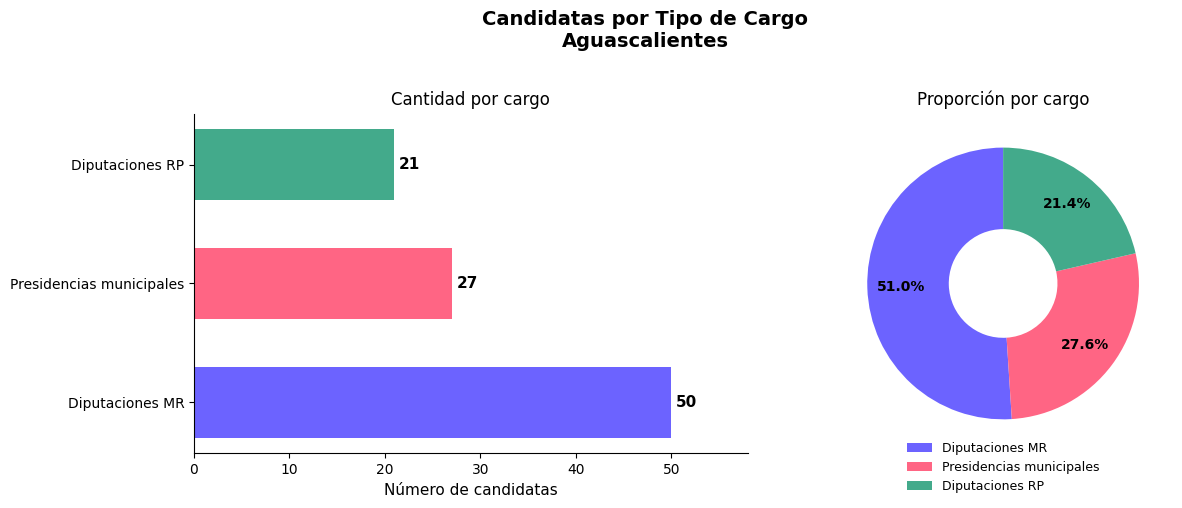


Tabla resumen:
                   Cargo  Candidatas  Porcentaje
         Diputaciones MR          50        51.0
Presidencias municipales          27        27.6
         Diputaciones RP          21        21.4


In [3]:
conteo_cargo = df['Cargo'].value_counts().reset_index()
conteo_cargo.columns = ['Cargo', 'Candidatas']
conteo_cargo['Porcentaje'] = (conteo_cargo['Candidatas'] / conteo_cargo['Candidatas'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Candidatas por Tipo de Cargo\nAguascalientes', fontsize=14, fontweight='bold', y=1.02)

# Barras horizontales
bars = axes[0].barh(
    conteo_cargo['Cargo'],
    conteo_cargo['Candidatas'],
    color=COLORES[:len(conteo_cargo)],
    edgecolor='none',
    height=0.6
)
for bar, val in zip(bars, conteo_cargo['Candidatas']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Número de candidatas', fontsize=11)
axes[0].set_title('Cantidad por cargo', fontsize=12)
axes[0].set_xlim(0, conteo_cargo['Candidatas'].max() + 8)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    conteo_cargo['Candidatas'],
    labels=None,
    autopct='%1.1f%%',
    colors=COLORES[:len(conteo_cargo)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].legend(
    conteo_cargo['Cargo'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    fontsize=9,
    frameon=False
)
axes[1].set_title('Proporción por cargo', fontsize=12)

plt.tight_layout()
plt.savefig('01_distribucion_cargo.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTabla resumen:')
print(conteo_cargo.to_string(index=False))

## 3. Cargo por partido político

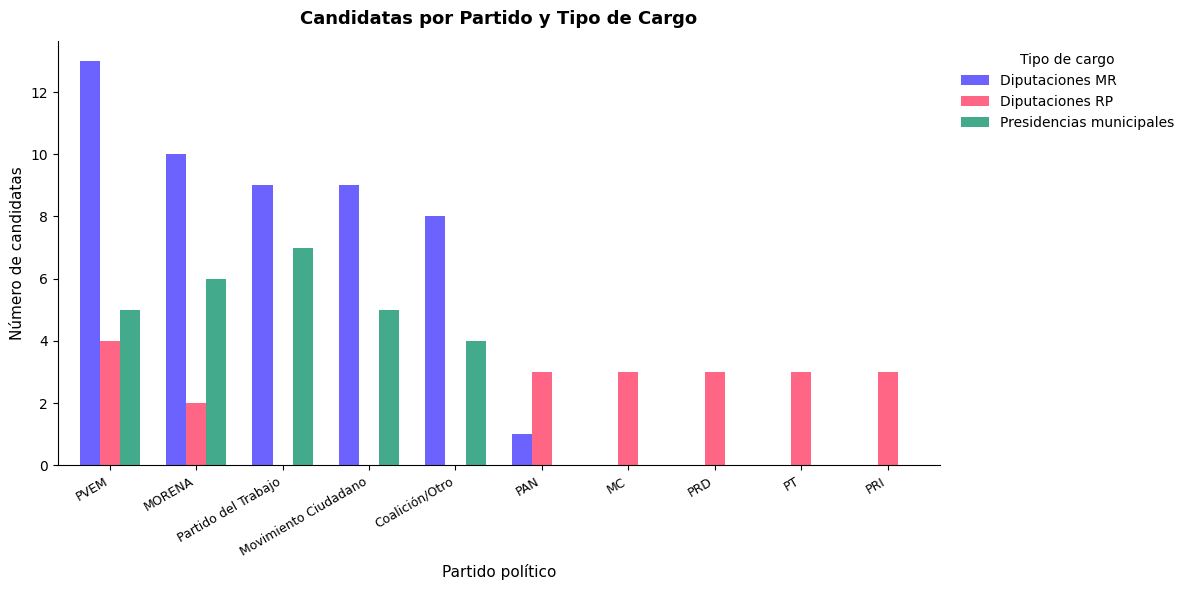


Tabla partido x cargo:
Cargo                 Diputaciones MR  Diputaciones RP  Presidencias municipales
Partido_limpio                                                                  
PVEM                               13                4                         5
MORENA                             10                2                         6
Partido del Trabajo                 9                0                         7
Movimiento Ciudadano                9                0                         5
Coalición/Otro                      8                0                         4
PAN                                 1                3                         0
MC                                  0                3                         0
PRD                                 0                3                         0
PT                                  0                3                         0
PRI                                 0                3                         0


In [4]:
# Limpiar partido (algunos están en 'Coalición' cuando partido es 'Sin información')
df['Partido_limpio'] = df['Partido político'].replace('Sin información', 'Coalición/Otro')

# Pivot: partidos x cargo
tabla = df.groupby(['Partido_limpio', 'Cargo']).size().unstack(fill_value=0)

# Ordenar por total descendente
tabla['Total'] = tabla.sum(axis=1)
tabla = tabla.sort_values('Total', ascending=False).drop(columns='Total')

fig, ax = plt.subplots(figsize=(12, 6))
tabla.plot(
    kind='bar',
    ax=ax,
    color=COLORES[:len(tabla.columns)],
    edgecolor='none',
    width=0.7
)
ax.set_title('Candidatas por Partido y Tipo de Cargo', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Partido político', fontsize=11)
ax.set_ylabel('Número de candidatas', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.legend(title='Tipo de cargo', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('02_cargo_partido.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTabla partido x cargo:')
print(tabla.to_string())

## 4. Diputaciones: MR vs RP

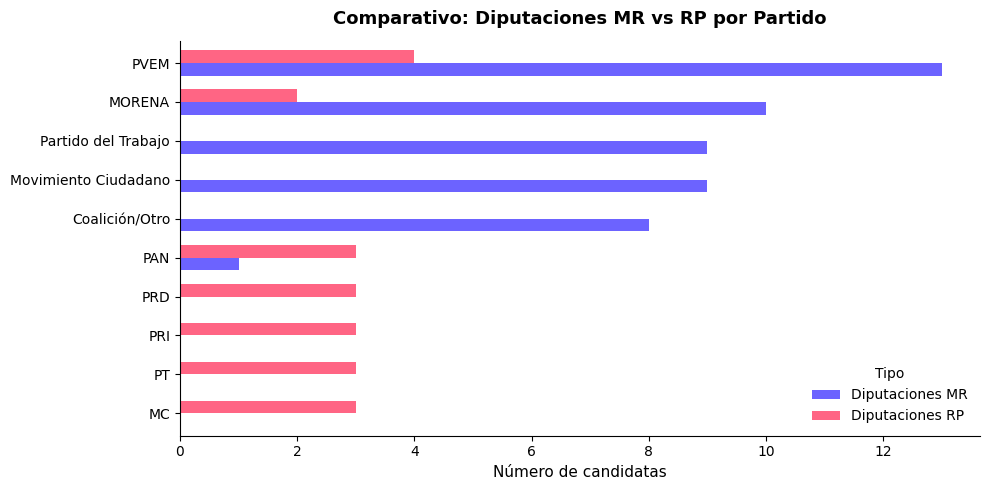

In [5]:
diputaciones = df[df['Cargo'].str.startswith('Diputaciones')].copy()

fig, ax = plt.subplots(figsize=(10, 5))

conteo = diputaciones.groupby(['Partido_limpio', 'Cargo']).size().unstack(fill_value=0)
conteo['Total'] = conteo.sum(axis=1)
conteo = conteo.sort_values('Total', ascending=True).drop(columns='Total')

conteo.plot(
    kind='barh',
    ax=ax,
    color=['#6C63FF', '#FF6584'],
    edgecolor='none',
    width=0.65
)
ax.set_title('Comparativo: Diputaciones MR vs RP por Partido', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Número de candidatas', fontsize=11)
ax.set_ylabel('')
ax.legend(title='Tipo', frameon=False)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('03_mr_vs_rp.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Presidencias municipales por municipio

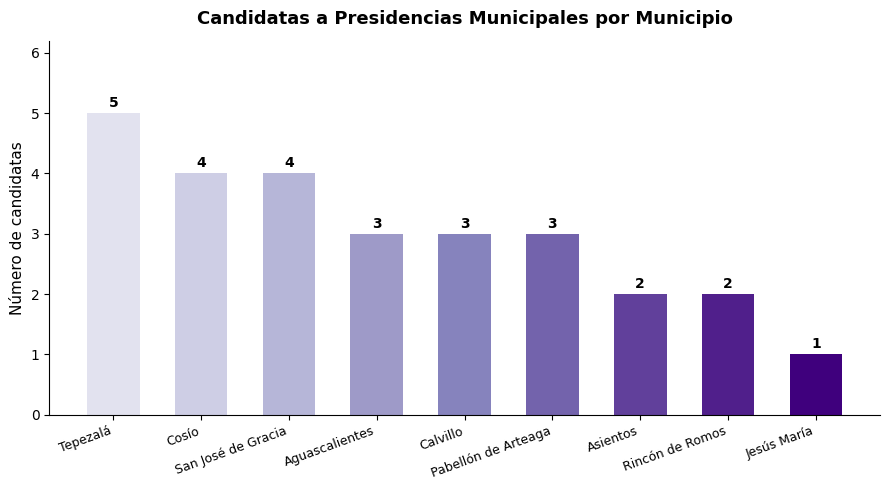

In [6]:
presidencias = df[df['Cargo'] == 'Presidencias municipales'].copy()
por_municipio = presidencias['Municipio'].value_counts().reset_index()
por_municipio.columns = ['Municipio', 'Candidatas']

colores_mun = plt.cm.get_cmap('Purples', len(por_municipio) + 2)
c_list = [colores_mun(i + 2) for i in range(len(por_municipio))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    por_municipio['Municipio'],
    por_municipio['Candidatas'],
    color=c_list,
    edgecolor='none',
    width=0.6
)
for bar, val in zip(bars, por_municipio['Candidatas']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Candidatas a Presidencias Municipales por Municipio', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Número de candidatas', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_ylim(0, por_municipio['Candidatas'].max() + 1.2)

plt.tight_layout()
plt.savefig('04_presidencias_municipio.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusiones

- **Diputaciones MR** concentran la mayor parte de las candidaturas femeninas (>50%), seguidas por Presidencias Municipales y Diputaciones RP.
- **MORENA, PVEM y Movimiento Ciudadano** presentan el mayor número de candidatas en todos los tipos de cargo.
- Las **Diputaciones de Representación Proporcional (RP)** son el mecanismo principal a través del cual partidos como PAN, PRI y PRD postulan mujeres.
- **Tepezalá** es el municipio con más candidatas a la presidencia municipal (5), reflejo de mayor competencia electoral en ese territorio.
- Solo se registró **1 candidatura a gubernatura**, lo que sugiere una barrera persistente en los cargos ejecutivos de mayor jerarquía.
